Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import linear_model

Import Dataset 

In [3]:
df=pd.read_csv(r"E:\Ayyan the analyst\Summer vacations\Python Project\AppleStore\AppleStore.csv")

First 5 Rows

In [4]:
df.head()

,id,track_name,size_bytes,currency,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
0,284882215,Facebook,389879808,USD,0.0,2974676,212,3.5,3.5,95.0,4+,Social Networking,37,1,29,1
1,389801252,Instagram,113954816,USD,0.0,2161558,1289,4.5,4.0,10.23,12+,Photo & Video,37,0,29,1
2,529479190,Clash of Clans,116476928,USD,0.0,2130805,579,4.5,4.5,9.24.12,9+,Games,38,5,18,1
3,420009108,Temple Run,65921024,USD,0.0,1724546,3842,4.5,4.0,1.6.2,9+,Games,40,5,1,1
4,284035177,Pandora - Music & Radio,130242560,USD,0.0,1126879,3594,4.0,4.5,8.4.1,12+,Music,37,4,1,1


Rows and Columns

In [5]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 7197
Columns: 16


Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7197 entries, 0 to 7196
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                7197 non-null   int64  
 1   track_name        7197 non-null   object 
 2   size_bytes        7197 non-null   int64  
 3   currency          7197 non-null   object 
 4   price             7197 non-null   float64
 5   rating_count_tot  7197 non-null   int64  
 6   rating_count_ver  7197 non-null   int64  
 7   user_rating       7197 non-null   float64
 8   user_rating_ver   7197 non-null   float64
 9   ver               7197 non-null   object 
 10  cont_rating       7197 non-null   object 
 11  prime_genre       7197 non-null   object 
 12  sup_devices.num   7197 non-null   int64  
 13  ipadSc_urls.num   7197 non-null   int64  
 14  lang.num          7197 non-null   int64  
 15  vpp_lic           7197 non-null   int64  
dtypes: float64(3), int64(8), object(5)
memory 

Checking Missing Values

In [7]:
df.isnull().sum()

id                  0
track_name          0
size_bytes          0
currency            0
price               0
rating_count_tot    0
rating_count_ver    0
user_rating         0
user_rating_ver     0
ver                 0
cont_rating         0
prime_genre         0
sup_devices.num     0
ipadSc_urls.num     0
lang.num            0
vpp_lic             0
dtype: int64

Checking Duplicate Values

In [8]:
df["id"].duplicated().sum()

np.int64(0)

Summary Statistics

In [9]:
df.describe()

,id,size_bytes,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
count,7.197000e+03,7.197000e+03,7197.000000,7.197000e+03,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000,7197.000000
mean,8.631310e+08,1.991345e+08,1.726218,1.289291e+04,460.373906,3.526956,3.253578,37.361817,3.707100,5.434903,0.993053
std,2.712368e+08,3.592069e+08,5.833006,7.573941e+04,3920.455183,1.517948,1.809363,3.737715,1.986005,7.919593,0.083066
min,2.816565e+08,5.898240e+05,0.000000,0.000000e+00,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,0.000000
25%,6.000937e+08,4.692275e+07,0.000000,2.800000e+01,1.000000,3.500000,2.500000,37.000000,3.000000,1.000000,1.000000
50%,9.781482e+08,9.715302e+07,0.000000,3.000000e+02,23.000000,4.000000,4.000000,37.000000,5.000000,1.000000,1.000000
75%,1.082310e+09,1.819249e+08,1.990000,2.793000e+03,140.000000,4.500000,4.500000,38.000000,5.000000,8.000000,1.000000
max,1.188376e+09,4.025970e+09,299.990000,2.974676e+06,177050.000000,5.000000,5.000000,47.000000,5.000000,75.000000,1.000000


Skewness and Kurtosis

In [10]:
skewness=df.skew(numeric_only="True")
kurtosis=df.kurtosis(numeric_only="True")

print("Skewness:",skewness)
print("Kurtosis:",kurtosis)

Skewness: id                  -0.719607
size_bytes           4.923980
price               31.415112
rating_count_tot    19.595199
rating_count_ver    26.425034
user_rating         -1.525420
user_rating_ver     -0.984432
sup_devices.num     -2.706104
ipadSc_urls.num     -1.151035
lang.num             2.867495
vpp_lic            -11.874585
dtype: float64
Kurtosis: id                    -0.969343
size_bytes            31.944569
price               1427.027126
rating_count_tot     567.346188
rating_count_ver     892.672124
user_rating            0.983266
user_rating_ver       -0.656424
sup_devices.num       10.352036
ipadSc_urls.num       -0.459935
lang.num              11.680762
vpp_lic              139.044410
dtype: float64


Distribution of user ratings

mean 3.526955675976101
Median 4.0
Mode 4.5


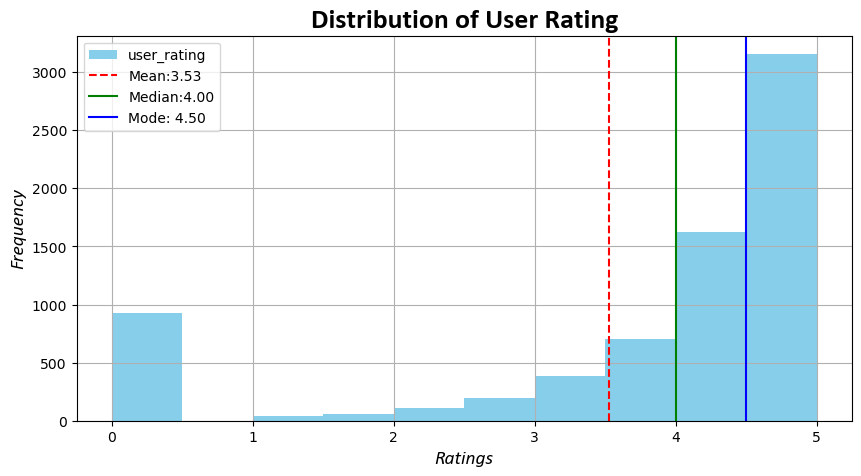

In [11]:
#Mean of User_Ratings
mean=df["user_rating"].mean()
print("mean",mean)

#Median of User Ratings
median=df["user_rating"].median()
print("Median", median)

#Mode of User Ratings
mode=df["user_rating"].mode()[0]
print("Mode",mode)

#Plot Histogram
plt.figure(figsize=(10,5))
df["user_rating"].plot(kind="hist",bins=10, color="skyblue")
plt.title("Distribution of User Rating" , fontweight="bold" , fontfamily="Calibri" , fontsize=20)
plt.xlabel("Ratings" , fontstyle="italic" , fontfamily="Calibri" , fontsize=14)
plt.ylabel("Frequency" , fontstyle="italic" , fontfamily="Calibri" , fontsize=14)
plt.axvline(mean , color="r" , linestyle="--" , label=f'Mean:{mean:.2f}')
plt.axvline(median , color="g" , linestyle="-" , label=f'Median:{median:.2f}')
plt.axvline(mode , color="b" , linestyle="-" , label=f'Mode: {mode:.2f}')
plt.legend()
plt.grid()
plt.show()





Price Distribution

Mean 1.726217868556343
Median 0.0
Mode 0.0


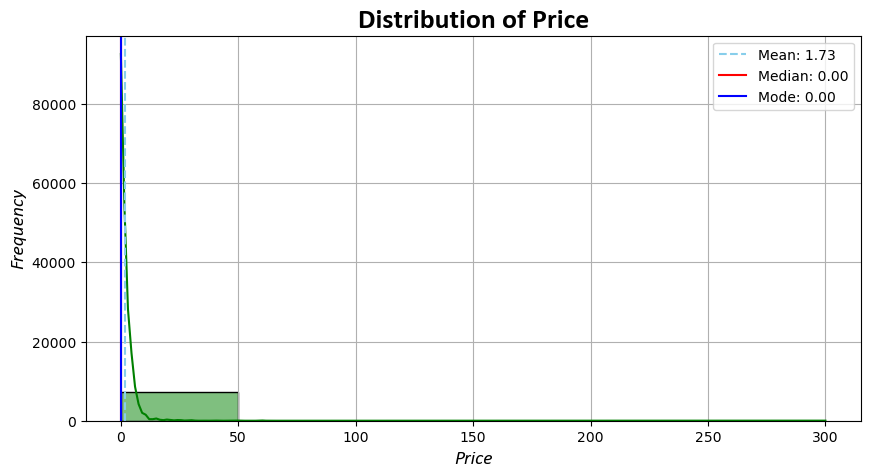

In [12]:
#Mean of Price
mean=df["price"].mean()
print("Mean" , mean)

#Median of Price
median=df["price"].median()
print("Median" , median)

#Mode of the Price
mode=df["price"].mode()[0]
print("Mode" , mode)

#Plot Histogram
plt.figure(figsize=(10,5))
sns.histplot(df["price"],kde=True,color="g" , bins=6)
plt.title("Distribution of Price" , fontfamily="Calibri" , fontweight="bold" , fontsize=20)
plt.xlabel("Price" , fontfamily="Calibri" , fontstyle="italic" , fontsize=14)
plt.ylabel("Frequency" , fontfamily="Calibri" , fontstyle="italic" , fontsize=14)
plt.axvline(mean , color="skyblue" , linestyle="--" , label=f'Mean: {mean:.2f}')
plt.axvline(median , color="r" , linestyle="-" , label=f'Median: {median:.2f}')
plt.axvline(mode , color="b" , linestyle="-" , label=f'Mode: {mode:.2f}')
plt.legend()
plt.grid()
plt.show()

Ratings Vs Popularity

Correlation 0.08330996604597418


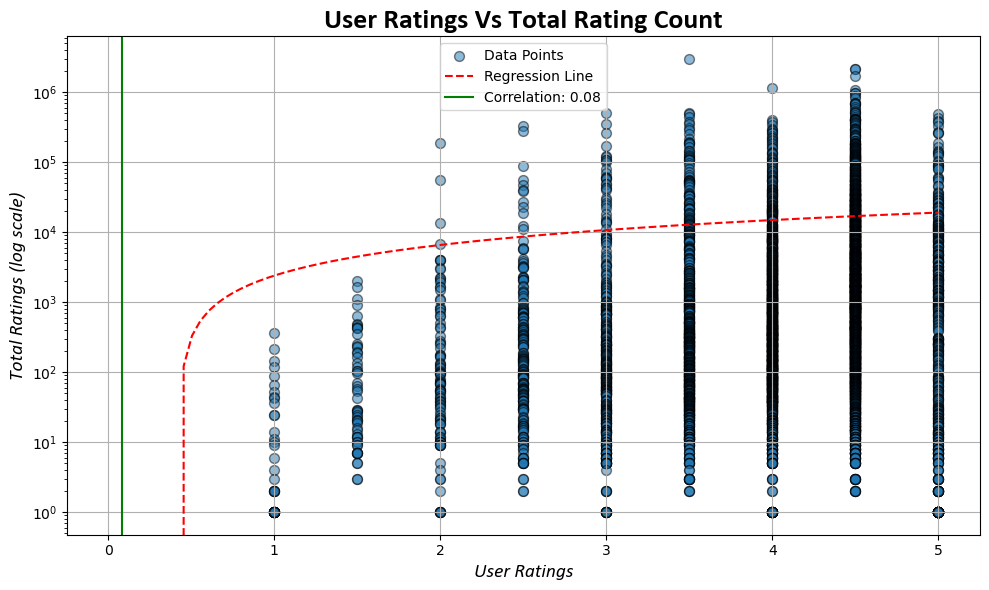

In [13]:
x=df["user_rating"]
y=df["rating_count_tot"]

#Correlation
correlation=x.corr(y)
print("Correlation" , correlation)

#Regression Line
m , b = np.polyfit(x,y,1)

#Scatter plot
plt.figure(figsize=(10,6))
plt.scatter(x , y , s=50 , alpha=0.5 , edgecolor="black" , linewidth=1 , label="Data Points")

#Add Regression line
x_line=np.linspace(x.min() , x.max(),100)
y_line=m*x_line+b
plt.plot(x_line ,y_line , linestyle="--" , color="r" , linewidth=1.5 , label="Regression Line")

#Correlation Line
plt.axvline(correlation , color="g" , linestyle="-" , label=f'Correlation: {correlation:.2f}')

#Logrithmic Y-Axis
plt.yscale("log")

#Title and Labels
plt.title("User Ratings Vs Total Rating Count" , fontfamily="Calibri" , fontweight="bold" , fontsize=20)
plt.xlabel("User Ratings" , fontfamily="Calibri" , fontstyle="italic" , fontsize=14)
plt.ylabel("Total Ratings (log scale)" , fontfamily="Calibri" ,fontstyle="italic" , fontsize=14)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

Correlation Analysis

Correlation of numeric columns:                         id  size_bytes     price  rating_count_tot  \
id                1.000000    0.077486 -0.075247         -0.201976   
size_bytes        0.077486    1.000000  0.182392          0.004486   
price            -0.075247    0.182392  1.000000         -0.039044   
rating_count_tot -0.201976    0.004486 -0.039044          1.000000   
rating_count_ver -0.072784    0.006337 -0.018012          0.163645   
user_rating      -0.185178    0.066256  0.046601          0.083310   
user_rating_ver  -0.109849    0.086075  0.025173          0.088744   
sup_devices.num   0.033605   -0.118347 -0.115361          0.008832   
ipadSc_urls.num   0.052082    0.152697  0.066100          0.015734   
lang.num         -0.128932    0.004614 -0.006713          0.137675   
vpp_lic           0.017743   -0.150418 -0.029942         -0.000982   

                  rating_count_ver  user_rating  user_rating_ver  \
id                       -0.072784    -0.185178        -0.1

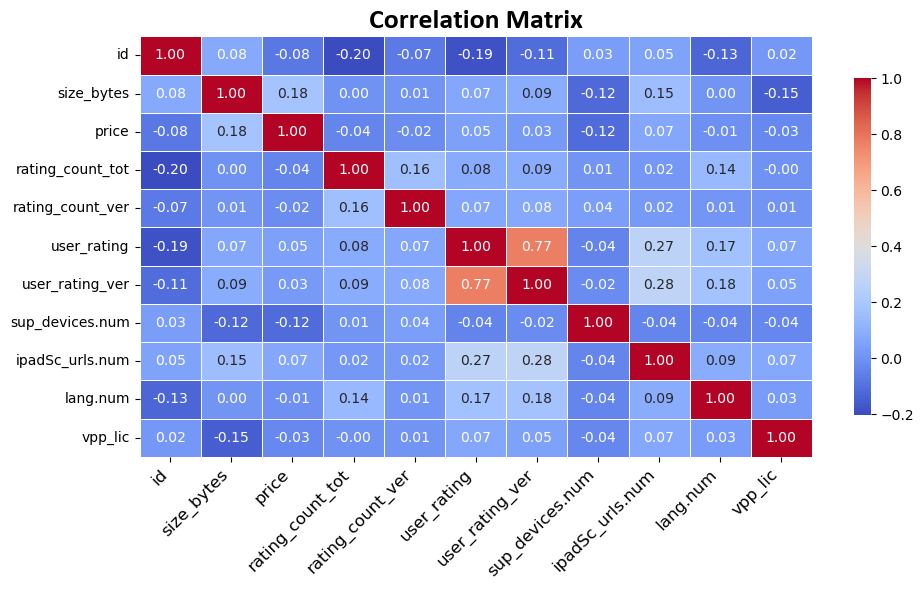

In [14]:
#Correlation
corr=df.corr(numeric_only=True)
print("Correlation of numeric columns:",corr)

#Mask
mask=np.triu(np.ones_like(corr , dtype=bool))

#Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr , annot=True , cmap="coolwarm" , fmt=".2f" , linewidth=0.5 , linecolor="white" , cbar_kws={"shrink":0.8}  )
plt.title("Correlation Matrix" , fontfamily="Calibri" , fontsize=20 , fontweight="bold")
plt.xticks(rotation=45 , ha="right" , fontsize=12)
mask=mask,
plt.tight_layout()
plt.show()

Statistical Analysis

Group ipad by user rating

In [15]:
df.groupby("ipadSc_urls.num")["user_rating"].agg(["count" , "mean" , "median" , "std"])

,count,mean,median,std
ipadSc_urls.num,,,,
0,1387,2.785148,3.5,1.879673
1,155,3.245161,3.5,1.437404
2,156,3.115385,3.5,1.662534
3,286,3.194056,4.0,1.658556
4,710,3.440845,4.0,1.555515
5,4503,3.814124,4.5,1.267036


T-Test

In [16]:
from scipy.stats import ttest_ind

In [17]:
group1=df[df["ipadSc_urls.num"]==1]["user_rating"]
group2=df[df["ipadSc_urls.num"]==0]["user_rating"]

t_Stat , p_value=ttest_ind(group1 , group2 , equal_var=False)

print("t_statistic:", t_Stat)
print("p_value:" , p_value)

t_statistic: 3.650761389184595
p_value: 0.00032748149064642227


Chi-Square Test

In [18]:
df["rating_category"]=pd.cut(
    df.user_rating,
    bins=[0,3,4,5],
    labels=["low","medium","high"],
    include_lowest=True)

Outlier Analysis

In [19]:
percentile_1=df["rating_count_tot"].quantile(0.25)
percentile_3=df["rating_count_tot"].quantile(0.75)

print("Percentile_1:", percentile_1)
print("Percentile_3:", percentile_3)

Percentile_1: 28.0
Percentile_3: 2793.0


In [20]:
IQR=percentile_3-percentile_1
print("IQR:",IQR)

IQR: 2765.0


In [21]:
lower=percentile_1-1.5*IQR
upper=percentile_3+1.5*IQR
print("Lower_Limit:",lower)
print("Upper_Limit:",upper)

Lower_Limit: -4119.5
Upper_Limit: 6940.5


In [22]:
outliers=df[(df["rating_count_tot"]<lower) | (df["rating_count_tot"])]
print("Outliers are:",outliers)

Outliers are:               id                            track_name  size_bytes currency  \
0      284882215                              Facebook   389879808      USD   
1      389801252                             Instagram   113954816      USD   
2      529479190                        Clash of Clans   116476928      USD   
3      420009108                            Temple Run    65921024      USD   
4      284035177               Pandora - Music & Radio   130242560      USD   
...          ...                                   ...         ...      ...   
6263  1080545293                    ナニワ金融道　全巻無料のマンガアプリ    38322176      USD   
6264  1055571047  There's no tablecloth I can't pull!!   168910848      USD   
6265  1141308767     Tinkerblocks – code, create, play   185029632      USD   
6266  1167445841      Advent Magnificat Companion 2016    53123072      USD   
6267  1089108246                おかんからのメッセ - ほのぼの謎解きゲーム    30749696      USD   

      price  rating_count_tot  rating

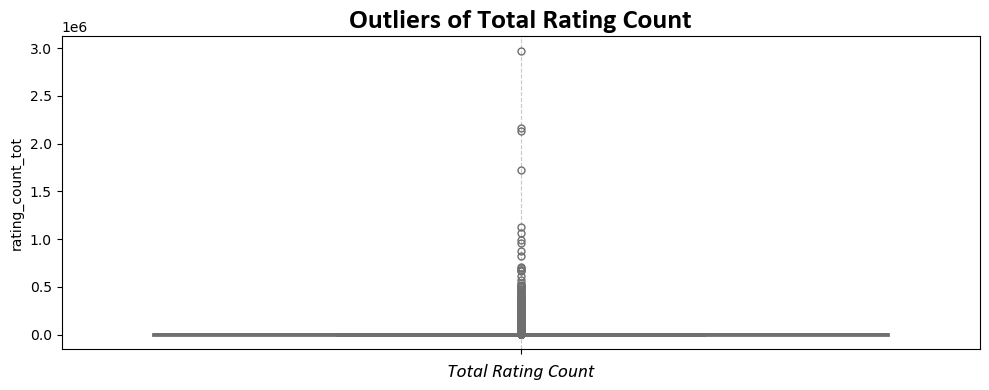

In [23]:
plt.figure(figsize=(10,4))

#Boxplot
sns.boxplot(df["rating_count_tot"], color="skyblue" , linewidth=2 , fliersize=5)
plt.title("Outliers of Total Rating Count" , fontweight="bold" , fontfamily="Calibri" , fontsize=20)
plt.xlabel("Total Rating Count" , fontstyle="italic" , fontsize=14 , fontfamily="Calibri")
plt.grid(axis="x" , linestyle="--" , alpha=0.7)
plt.tight_layout()
plt.show()

Regression

In [24]:
reg=linear_model.LinearRegression()
reg.fit(df[["sup_devices.num"]],df["user_rating"])

LinearRegression()

In [25]:
reg.coef_

array([-0.01724024])

In [26]:
reg.intercept_

np.float64(4.171082281451497)

In [27]:
reg.predict([[4.0]])

C:\Users\Muhammad Zarian\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([4.10212133])

In [28]:
#Regression Equation
#y=mx+b

y=-0.01724024*4.0+4.171082281451497
print("regression=",y)

regression= 4.102121321451497


In [29]:
import statsmodels.api as sm

In [30]:
x=df["sup_devices.num"]
y=df["user_rating"]
#Adding Intercept to model otherwise its start from zero
x=sm.add_constant(x)
#OLS(Ordinary Least Square) Minimizes the square difference between actual and prediction rating
model=sm.OLS(y,x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            user_rating   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     12.99
Date:                Thu, 03 Sep 2026   Prob (F-statistic):           0.000315
Time:                        08:11:44   Log-Likelihood:                -13209.
No. Observations:                7197   AIC:                         2.642e+04
Df Residuals:                    7195   BIC:                         2.644e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.1711      0.180     

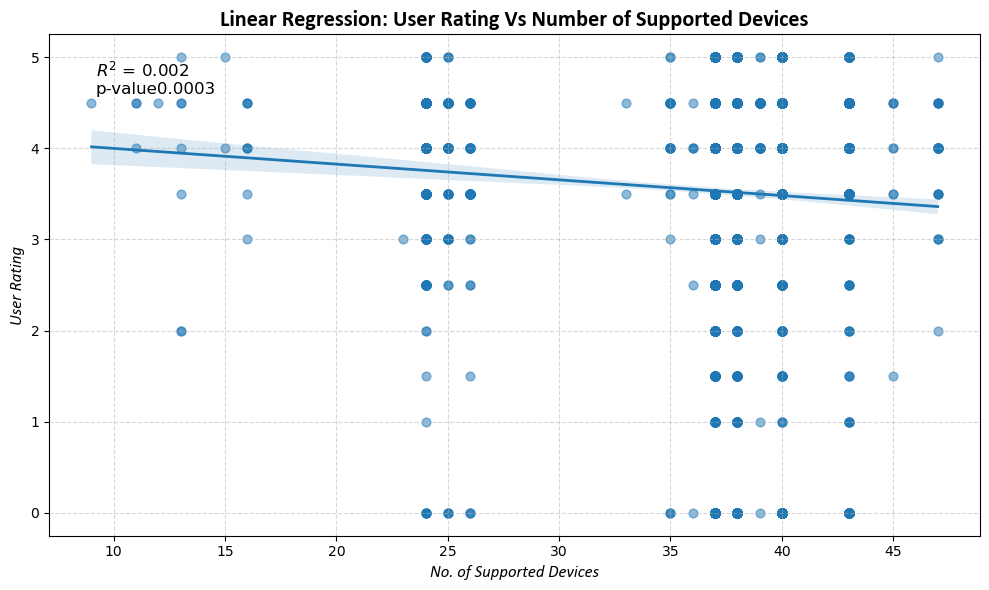

In [31]:
plt.figure(figsize=(10,6))
#Regression plot
sns.regplot(x=df["sup_devices.num"] , y=df["user_rating"] , scatter_kws={"alpha":0.5 , "s":40} , line_kws={"linewidth":2})
plt.title("Linear Regression: User Rating Vs Number of Supported Devices"  , fontfamily="Calibri" , fontsize=16 , fontweight="bold")
plt.xlabel("No. of Supported Devices" , fontfamily="Calibri" , fontstyle="italic" , fontsize=12)
plt.ylabel("User Rating" , fontfamily="Calibri" , fontsize=12 , fontstyle="italic")
plt.text(0.05,0.95,f'$R^2$ = {model.rsquared:.3f}\n'
         f'p-value{model.pvalues["sup_devices.num"]:.4f}',
transform=plt.gca().transAxes, verticalalignment="top",fontsize=12)
plt.grid(True , linestyle="--" , alpha=0.5)
plt.tight_layout()
plt.show()


Probability Distribution

In [32]:
df["rating_success"]=(df["user_rating"]>4).astype(int)

In [33]:
df.head()

,id,track_name,size_bytes,currency,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic,rating_category,rating_success
0,284882215,Facebook,389879808,USD,0.0,2974676,212,3.5,3.5,95.0,4+,Social Networking,37,1,29,1,medium,0
1,389801252,Instagram,113954816,USD,0.0,2161558,1289,4.5,4.0,10.23,12+,Photo & Video,37,0,29,1,high,1
2,529479190,Clash of Clans,116476928,USD,0.0,2130805,579,4.5,4.5,9.24.12,9+,Games,38,5,18,1,high,1
3,420009108,Temple Run,65921024,USD,0.0,1724546,3842,4.5,4.0,1.6.2,9+,Games,40,5,1,1,high,1
4,284035177,Pandora - Music & Radio,130242560,USD,0.0,1126879,3594,4.0,4.5,8.4.1,12+,Music,37,4,1,1,medium,0


Rating_success
1=Success
0=Failure

In [34]:
df["rating_success"].value_counts()

rating_success
0    4042
1    3155
Name: count, dtype: int64

In [35]:
p=df['rating_success'].mean()
print("probability of success",p)

probability of success 0.4383771015700986


In [36]:
from scipy.stats import binom

n=10
x=range(0,n+1)

probability=binom.pmf(x,n,p)
print("Probability:",probability)

Probability: [0.00312211 0.02436975 0.08559861 0.1781716  0.24337702 0.22796274
 0.14828106 0.06613794 0.01935909 0.00335796 0.00026211]


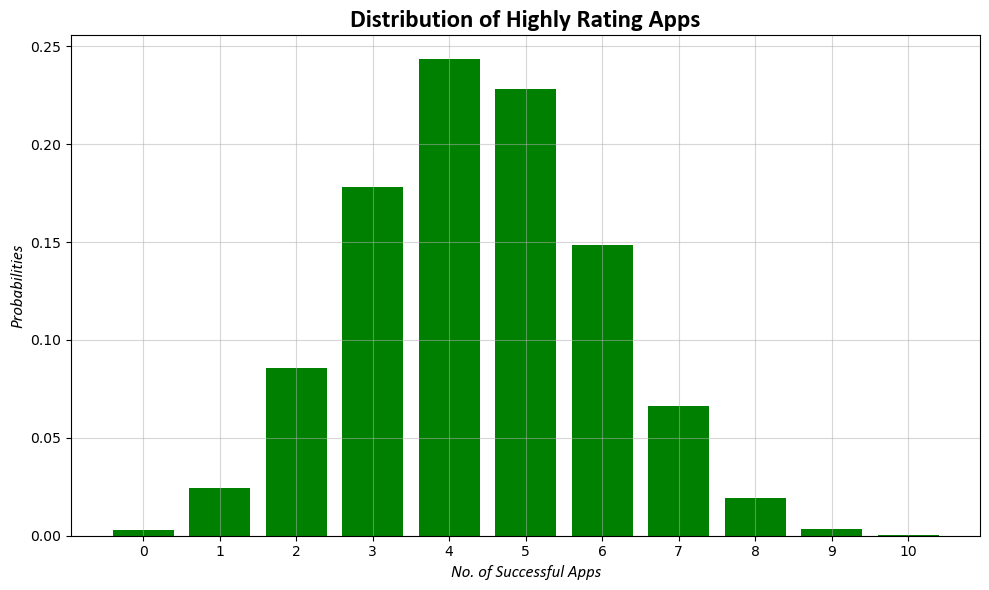

In [37]:
plt.figure(figsize=(10,6))
plt.bar(x , probability , color="g" )
plt.title("Distribution of Highly Rating Apps" , fontfamily="Calibri" , fontweight="bold" , fontsize=18)
plt.xlabel("No. of Successful Apps" , fontfamily="Calibri" , fontsize=12 , fontstyle="italic")
plt.ylabel("Probabilities" , fontfamily="Calibri" , fontsize=12 , fontstyle="italic")
plt.grid(alpha=0.5)
plt.xticks(range(0,11))
plt.tight_layout()
plt.show()

Free Vs Paid Apps

In [38]:
df["app_type"]=df["price"].apply(lambda x: 'Free' if x==0 else 'paid')
df.app_type.value_counts()

app_type
Free    4056
paid    3141
Name: count, dtype: int64

In [45]:
rating_by_type=df.groupby("app_type")["user_rating"].agg(['count','mean','std','median'])
print(rating_by_type)

          count      mean       std  median
app_type                                   
Free       4056  3.376726  1.644807     4.0
paid       3141  3.720949  1.311471     4.0


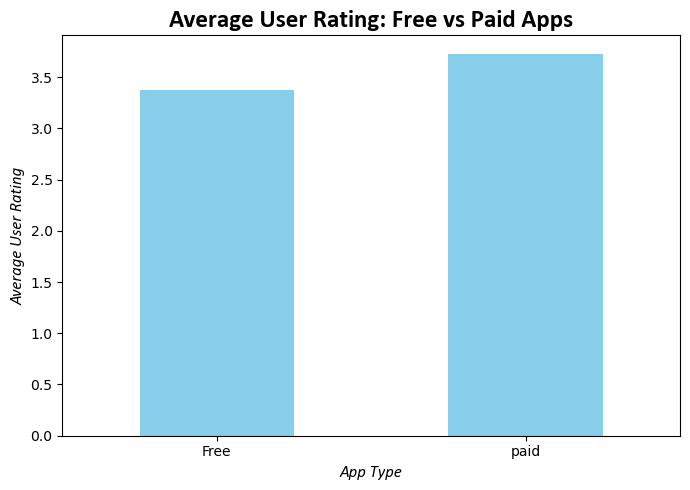

In [50]:
plt.figure(figsize=(7, 5))

df.groupby("app_type")["user_rating"].mean().plot(
    kind="bar" , color='skyblue' 
)

plt.title("Average User Rating: Free vs Paid Apps" , fontfamily="Calibri" , fontweight="bold" , fontsize=18)
plt.xlabel("App Type", fontstyle="italic" , fontfamily="Calibri" , fontsize=12)
plt.ylabel("Average User Rating", fontstyle="italic" , fontfamily="Calibri" , fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Genre_rating ( Which genre has higher genre rating?)

In [53]:
genre_rating=df.groupby('prime_genre')['user_rating'].agg(['mean','count']).sort_values('mean' , ascending=False)
print(genre_rating.head(10))

                      mean  count
prime_genre                      
Productivity      4.005618    178
Music             3.978261    138
Photo & Video     3.800860    349
Business          3.745614     57
Health & Fitness  3.700000    180
Games             3.685008   3862
Weather           3.597222     72
Shopping          3.540984    122
Reference         3.453125     64
Travel            3.376543     81


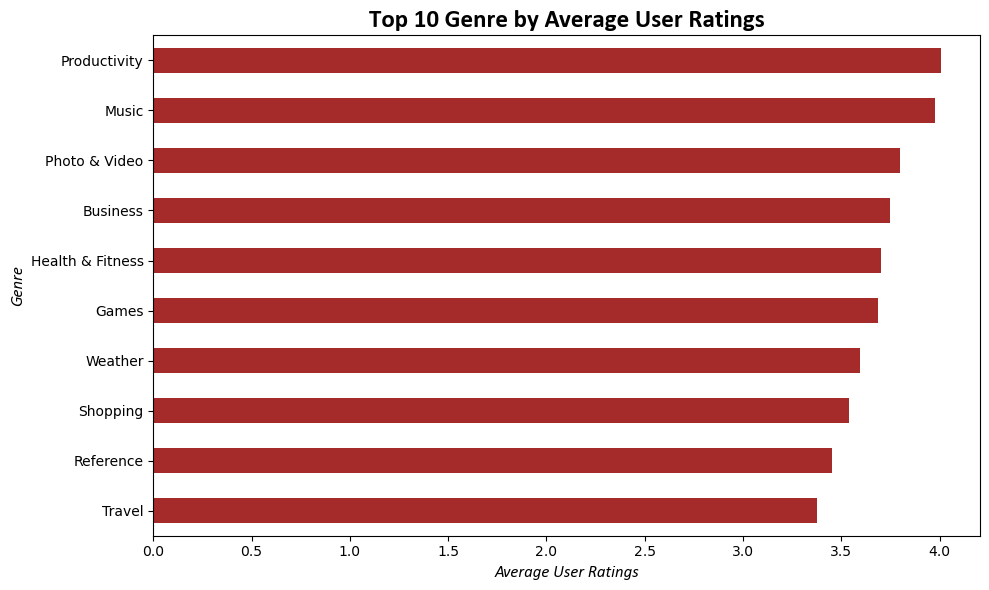

In [59]:
top_genres=genre_rating.head(10)

plt.figure(figsize=(10,6))
top_genres["mean"].sort_values().plot(kind="barh" , color="brown" )
plt.title("Top 10 Genre by Average User Ratings" , fontfamily="Calibri" , fontsize=18 , fontweight="bold")
plt.xlabel("Average User Ratings" , fontfamily="Calibri" , fontsize=12 , fontstyle="italic")
plt.ylabel("Genre" , fontfamily="Calibri" , fontsize=12 , fontstyle="italic")
plt.tight_layout()
plt.show()


App Popularity

In [60]:
correlation = df[
    [
        "price",
        "user_rating",
        "sup_devices.num",
        "ipadSc_urls.num",
        "lang.num",
        "rating_count_tot"
    ]
].corr()["rating_count_tot"].sort_values(ascending=False)

print(correlation)

rating_count_tot    1.000000
lang.num            0.137675
user_rating         0.083310
ipadSc_urls.num     0.015734
sup_devices.num     0.008832
price              -0.039044
Name: rating_count_tot, dtype: float64


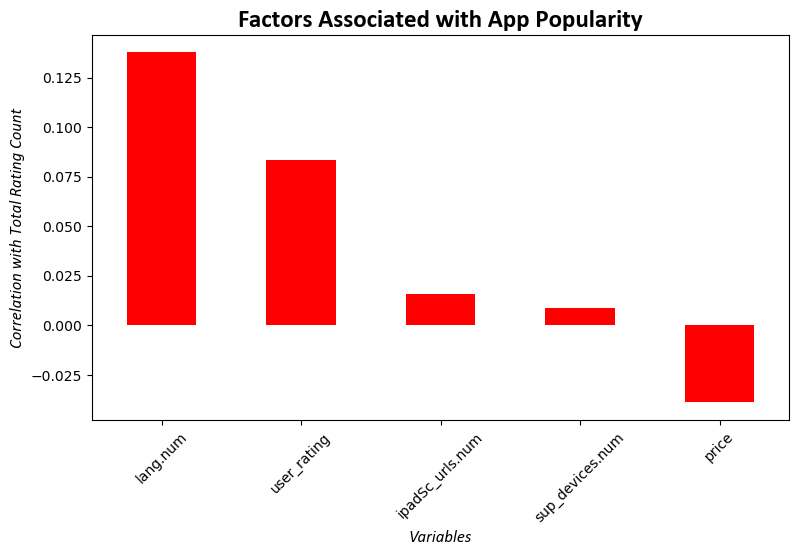

In [65]:
correlation.drop("rating_count_tot").plot(
    kind="bar", color="red",
    figsize=(9, 5)
)

plt.title("Factors Associated with App Popularity", fontfamily="Calibri" , fontsize=18 , fontweight="bold")
plt.xlabel("Variables", fontfamily="Calibri" , fontsize=12 , fontstyle="italic")
plt.ylabel("Correlation with Total Rating Count", fontfamily="Calibri" , fontsize=12 , fontstyle="italic")

plt.xticks(rotation=45)
plt.show()